#  CHAPITRE 1 COMPLET — DTMC sur données NSL-KDD réelles



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from math import gcd
import warnings
warnings.filterwarnings('ignore')
 
np.set_printoptions(precision=4, suppress=True)

#  PARTIE 0 : Chargement et préparation du dataset NSL-KDD


In [3]:
# ================================================================
#  CHARGEMENT DU VRAI DATASET NSL-KDD
#  Instructions : place KDDTrain+.txt dans le même dossier que
#  ce script, puis lance : python charger_nslkdd.py
# ================================================================

CHEMIN = r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\dataset\KDDTrain+.txt'
 
# ── Colonnes officielles NSL-KDD ──
COLONNES = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent',
    'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count',
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]
 
ATTACK_MAP = {
    'normal': 'normal',
    'back':'dos','land':'dos','neptune':'dos','pod':'dos','smurf':'dos',
    'teardrop':'dos','apache2':'dos','udpstorm':'dos','processtable':'dos','worm':'dos',
    'ipsweep':'probe','nmap':'probe','portsweep':'probe','satan':'probe',
    'mscan':'probe','saint':'probe',
    'ftp_write':'r2l','guess_passwd':'r2l','imap':'r2l','multihop':'r2l',
    'phf':'r2l','spy':'r2l','warezclient':'r2l','warezmaster':'r2l',
    'sendmail':'r2l','named':'r2l','snmpgetattack':'r2l','snmpguess':'r2l',
    'xlock':'r2l','xsnoop':'r2l','httptunnel':'r2l',
    'buffer_overflow':'u2r','loadmodule':'u2r','perl':'u2r','rootkit':'u2r',
    'mailbomb':'u2r','ps':'u2r','sqlattack':'u2r','xterm':'u2r'
}
 
# ── Charger directement les vraies données ──
import pandas as pd
import numpy as np
 
df = pd.read_csv(CHEMIN, header=None, names=COLONNES)
df['attack_cat'] = df['label'].map(ATTACK_MAP).fillna('other')
 
print("=" * 65)
print("  CHAPITRE 1 — DTMC appliquée à NSL-KDD (Sécurité Réseau)")
print("=" * 65)
print(f"\n[DATASET] NSL-KDD — {len(df)} connexions chargées  ← VRAIES DONNÉES")
print(f"  Features utilisées : duration, service, flag, num_failed_logins,")
print(f"                       serror_rate, rerror_rate")
print(f"\n  Distribution des types de trafic :")
for cat, cnt in df['attack_cat'].value_counts().items():
    pct = cnt/len(df)*100
    barre = '█' * int(pct/3)
    print(f"    {cat:10s} : {cnt:6d} connexions  ({pct:.1f}%)  {barre}")
 

def charger_nslkdd(chemin_fichier):
    """
    Charge le fichier KDDTrain+.txt et retourne un DataFrame propre.
    """
    if not os.path.exists(chemin_fichier):
        print(f"❌ Fichier non trouvé : {chemin_fichier}")
        print("   → Place KDDTrain+.txt dans le même dossier que ce script.")
        return None

    df = pd.read_csv(chemin_fichier, header=None, names=COLONNES)
    df['attack_cat'] = df['label'].map(ATTACK_MAP).fillna('other')

    print(f"✅ Dataset chargé : {len(df)} connexions, {df.shape[1]} colonnes")
    print(f"\n📊 Distribution des catégories d'attaque :")
    for cat, cnt in df['attack_cat'].value_counts().items():
        pct = cnt / len(df) * 100
        barre = '█' * int(pct / 2)
        print(f"   {cat:10s} : {cnt:6d}  ({pct:5.1f}%)  {barre}")

    print(f"\n🔍 Features clés utilisées pour le Chapitre 1 :")
    print(df[['duration','service','flag','num_failed_logins',
              'serror_rate','rerror_rate','label','attack_cat']].head(10).to_string())
    return df


def classifier_etat(row):
    """
    Classe chaque connexion NSL-KDD en état réseau (0-3).
    Basé sur les features réelles du dataset.
    """
    cat = row['attack_cat']
    flag = row['flag']
    fails = row['num_failed_logins']
    serr = row['serror_rate']
    rerr = row['rerror_rate']

    if cat == 'normal':
        if fails == 0 and flag == 'SF':
            return 0  # Normal — connexion saine complète
        else:
            return 1  # Suspect — connexion normale mais comportement inhabituel

    elif cat == 'probe':
        return 1      # Suspect — phase de reconnaissance

    elif cat == 'dos':
        if serr > 0.7:
            return 2  # Compromis — DoS actif avec beaucoup d'erreurs SYN
        else:
            return 1  # Suspect — DoS naissant

    elif cat in ['r2l', 'u2r']:
        return 2      # Compromis — accès non autorisé ou élévation de privilèges

    else:
        return 1      # Suspect par défaut


# ── UTILISATION ──
# Remplace 'KDDTrain+.txt' par le chemin exact sur ton PC
# Exemples :
#   Windows : r'C:\Users\Fidaa\Downloads\KDDTrain+.txt'
#   Linux   : '/home/fidaa/datasets/KDDTrain+.txt'

CHEMIN = r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\dataset\KDDTrain+.txt'   # ← change ici si besoin

df = charger_nslkdd(CHEMIN)

if df is not None:
    # Ajouter les états
    df['etat'] = df.apply(classifier_etat, axis=1)

    # Ajouter état Récupéré (3) : connexion normale juste après un état Compromis
    for i in range(1, len(df)):
        if df.iloc[i-1]['etat'] == 2 and df.iloc[i]['attack_cat'] == 'normal':
            df.at[df.index[i], 'etat'] = 3

    ETATS = {0: "Normal", 1: "Suspect", 2: "Compromis", 3: "Récupéré"}
    print(f"\n📌 Distribution des états Markov :")
    for i in range(4):
        cnt = (df['etat'] == i).sum()
        print(f"   {ETATS[i]:12s} : {cnt:6d}  ({cnt/len(df)*100:.1f}%)")

    # Sauvegarder pour utilisation dans ch1_nslkdd_complet.py
    df.to_csv('nslkdd_sample.csv', index=False)
    print(f"\n✅ Fichier nslkdd_sample.csv créé — prêt pour ch1_nslkdd_complet.py")

  CHAPITRE 1 — DTMC appliquée à NSL-KDD (Sécurité Réseau)

[DATASET] NSL-KDD — 125973 connexions chargées  ← VRAIES DONNÉES
  Features utilisées : duration, service, flag, num_failed_logins,
                       serror_rate, rerror_rate

  Distribution des types de trafic :
    normal     :  67343 connexions  (53.5%)  █████████████████
    dos        :  45927 connexions  (36.5%)  ████████████
    probe      :  11656 connexions  (9.3%)  ███
    r2l        :    995 connexions  (0.8%)  
    u2r        :     52 connexions  (0.0%)  
✅ Dataset chargé : 125973 connexions, 44 colonnes

📊 Distribution des catégories d'attaque :
   normal     :  67343  ( 53.5%)  ██████████████████████████
   dos        :  45927  ( 36.5%)  ██████████████████
   probe      :  11656  (  9.3%)  ████
   r2l        :    995  (  0.8%)  
   u2r        :     52  (  0.0%)  

🔍 Features clés utilisées pour le Chapitre 1 :
   duration     service flag  num_failed_logins  serror_rate  rerror_rate    label attack_cat
0     

In [4]:
print("=" * 65)
print("  CHAPITRE 1 — DTMC appliquée à NSL-KDD (Sécurité Réseau)")
print("=" * 65)
 
df = pd.read_csv(r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\dataset\nslkdd_sample.csv')
 
print(f"\n[DATASET] NSL-KDD — {len(df)} connexions chargées")
print(f"  Features utilisées : duration, service, flag, num_failed_logins,")
print(f"                       serror_rate, rerror_rate")
print(f"\n  Distribution des types de trafic :")
for cat, cnt in df['attack_cat'].value_counts().items():
    print(f"    {cat:10s} : {cnt:5d} connexions  ({cnt/len(df)*100:.1f}%)")

  CHAPITRE 1 — DTMC appliquée à NSL-KDD (Sécurité Réseau)

[DATASET] NSL-KDD — 5000 connexions chargées
  Features utilisées : duration, service, flag, num_failed_logins,
                       serror_rate, rerror_rate

  Distribution des types de trafic :
    normal     :  2500 connexions  (50.0%)
    probe      :  1350 connexions  (27.0%)
    dos        :  1150 connexions  (23.0%)


#  PARTIE 1 : Processus Stochastique — Définition des états


In [5]:
def classifier_etat_nslkdd(row):
    """
    Règles de classification d'une connexion NSL-KDD en état réseau.
    Basé sur : flag, num_failed_logins, serror_rate, rerror_rate, attack_cat
    """
    if row['attack_cat'] == 'normal':
        if row['num_failed_logins'] == 0 and row['flag'] == 'SF':
            return 0  # Normal
        else:
            return 1  # Suspect (connexion normale mais comportement inhabituel)
    elif row['attack_cat'] == 'probe':
        return 1      # Suspect (scan/sonde = phase de reconnaissance)
    elif row['attack_cat'] == 'dos':
        if row['serror_rate'] > 0.7:
            return 2  # Compromis (attaque DoS active)
        else:
            return 1  # Suspect
    else:
        return 2      # Compromis
 
df['etat'] = df.apply(classifier_etat_nslkdd, axis=1)
 
# Ajouter état Récupéré (état 3) : connexions normales après une connexion suspecte
for i in range(1, len(df)):
    if df.iloc[i-1]['etat'] == 2 and df.iloc[i]['attack_cat'] == 'normal':
        df.at[df.index[i], 'etat'] = 3
 
ETATS = {0: "Normal", 1: "Suspect", 2: "Compromis", 3: "Récupéré"}
NOMS  = [ETATS[i] for i in range(4)]
 
print("\n" + "=" * 65)
print("PARTIE 1 — Processus Stochastique : États définis depuis NSL-KDD")
print("=" * 65)
print("\n  Règle de classification :")
print("    normal + flag=SF + 0 échec login  → État 0 : Normal")
print("    probe (scan/reconnaissance)        → État 1 : Suspect")
print("    dos + serror_rate > 0.7            → État 2 : Compromis")
print("    normal après Compromis             → État 3 : Récupéré")
print("\n  Distribution des états dans NSL-KDD :")
for i in range(4):
    cnt = (df['etat'] == i).sum()
    print(f"    État {i} ({ETATS[i]:12s}) : {cnt:5d}  ({cnt/len(df)*100:.1f}%)")


PARTIE 1 — Processus Stochastique : États définis depuis NSL-KDD

  Règle de classification :
    normal + flag=SF + 0 échec login  → État 0 : Normal
    probe (scan/reconnaissance)        → État 1 : Suspect
    dos + serror_rate > 0.7            → État 2 : Compromis
    normal après Compromis             → État 3 : Récupéré

  Distribution des états dans NSL-KDD :
    État 0 (Normal      ) :  1884  (37.7%)
    État 1 (Suspect     ) :  1920  (38.4%)
    État 2 (Compromis   ) :   800  (16.0%)
    État 3 (Récupéré    ) :   396  (7.9%)


#  PARTIE 2 : Matrice de transition depuis NSL-KDD


In [6]:
def calculer_matrice_transition(series_etats, n_etats=4):
    """
    Calcule la matrice de transition empirique depuis une séquence d'états.
    P[i,j] = nombre de transitions i→j / nombre total de départs depuis i
    """
    counts = np.zeros((n_etats, n_etats), dtype=int)
    etats = series_etats.values
    for t in range(len(etats) - 1):
        i, j = int(etats[t]), int(etats[t+1])
        if 0 <= i < n_etats and 0 <= j < n_etats:
            counts[i, j] += 1
 
    # Normaliser chaque ligne
    P = np.zeros((n_etats, n_etats))
    for i in range(n_etats):
        total = counts[i].sum()
        if total > 0:
            P[i] = counts[i] / total
        else:
            P[i, i] = 1.0  # état absorbant si jamais observé
 
    return P, counts
 
P, counts = calculer_matrice_transition(df['etat'])
 
print("\n" + "=" * 65)
print("PARTIE 2 — Matrice de transition P (calculée depuis NSL-KDD)")
print("=" * 65)
print(f"\n  Matrice de comptage des transitions :")
header = f"{'':14s}" + "".join(f"{n:>13s}" for n in NOMS)
print(header)
for i in range(4):
    row = f"  {NOMS[i]:12s}" + "".join(f"{counts[i,j]:>13d}" for j in range(4))
    print(row)
 
print(f"\n  Matrice P (probabilités de transition) :")
print(header)
for i in range(4):
    row = f"  {NOMS[i]:12s}" + "".join(f"{P[i,j]:>13.4f}" for j in range(4))
    print(row)
 
print(f"\n  Vérification somme des lignes = 1 :")
for i in range(4):
    print(f"    {NOMS[i]:12s} : {P[i].sum():.6f}")


PARTIE 2 — Matrice de transition P (calculée depuis NSL-KDD)

  Matrice de comptage des transitions :
                     Normal      Suspect    Compromis     Récupéré
  Normal                839          729          315            0
  Suspect               857          775          288            0
  Compromis               0          268          136          396
  Récupéré              187          148           61            0

  Matrice P (probabilités de transition) :
                     Normal      Suspect    Compromis     Récupéré
  Normal             0.4456       0.3871       0.1673       0.0000
  Suspect            0.4464       0.4036       0.1500       0.0000
  Compromis          0.0000       0.3350       0.1700       0.4950
  Récupéré           0.4722       0.3737       0.1540       0.0000

  Vérification somme des lignes = 1 :
    Normal       : 1.000000
    Suspect      : 1.000000
    Compromis    : 1.000000
    Récupéré     : 1.000000


#  PARTIE 3a : Graphe représentatif


In [7]:
G = nx.DiGraph()
G.add_nodes_from(range(4))
for i in range(4):
    for j in range(4):
        if P[i, j] > 0.01:   # seuil pour ne pas afficher les transitions rares
            G.add_edge(i, j, weight=P[i, j])
 
print("\n" + "=" * 65)
print("PARTIE 3a — Graphe représentatif")
print("=" * 65)
print(f"\n  Arêtes significatives (P > 0.01) :")
for (i, j, d) in G.edges(data=True):
    print(f"    {NOMS[i]:12s} → {NOMS[j]:12s} : {d['weight']:.4f}")


PARTIE 3a — Graphe représentatif

  Arêtes significatives (P > 0.01) :
    Normal       → Normal       : 0.4456
    Normal       → Suspect      : 0.3871
    Normal       → Compromis    : 0.1673
    Suspect      → Normal       : 0.4464
    Suspect      → Suspect      : 0.4036
    Suspect      → Compromis    : 0.1500
    Compromis    → Suspect      : 0.3350
    Compromis    → Compromis    : 0.1700
    Compromis    → Récupéré     : 0.4950
    Récupéré     → Normal       : 0.4722
    Récupéré     → Suspect      : 0.3737
    Récupéré     → Compromis    : 0.1540


#  PARTIE 3b : Classification des états


In [8]:
def classer_etats_complet(P, noms):
    """
    Classification complète :
    - Communicabilité (i ↔ j) via composantes fortement connexes
    - Récurrent vs Transitoire
    - Période de chaque état
    """
    n = P.shape[0]
    G_class = nx.DiGraph()
    G_class.add_nodes_from(range(n))
    for i in range(n):
        for j in range(n):
            if P[i, j] > 1e-10:
                G_class.add_edge(i, j)
 
    sccs = list(nx.strongly_connected_components(G_class))
    resultats = {}
 
    for scc in sccs:
        scc_sorted = sorted(scc)
        # Récurrent = aucune arête ne sort de la SCC
        est_recurrente = all(
            all(succ in scc for succ in G_class.successors(i))
            for i in scc
        )
        for i in scc_sorted:
            resultats[i] = {
                'classe_comm': scc_sorted,
                'type': 'récurrent' if est_recurrente else 'transitoire',
                'taille_classe': len(scc_sorted)
            }
    return resultats, G_class, sccs
 
classif, G_class, sccs = classer_etats_complet(P, NOMS)
 
print("\n" + "=" * 65)
print("PARTIE 3b — Classification des états et classes de communication")
print("=" * 65)
print(f"\n  Classes de communication (SCC) :")
for k, scc in enumerate(sccs):
    noms_scc = [NOMS[i] for i in sorted(scc)]
    est_rec = all(classif[i]['type'] == 'récurrent' for i in scc)
    print(f"    Classe {k+1} : {noms_scc}  →  {'récurrente' if est_rec else 'transitoire'}")
 
print(f"\n  Classification état par état :")
for i in range(4):
    c = classif[i]
    print(f"    {NOMS[i]:12s} : {c['type']:12s} | classe = {[NOMS[j] for j in c['classe_comm']]}")
 
irreductible = nx.is_strongly_connected(G_class)
print(f"\n  La chaîne est irréductible : {irreductible}")


PARTIE 3b — Classification des états et classes de communication

  Classes de communication (SCC) :
    Classe 1 : ['Normal', 'Suspect', 'Compromis', 'Récupéré']  →  récurrente

  Classification état par état :
    Normal       : récurrent    | classe = ['Normal', 'Suspect', 'Compromis', 'Récupéré']
    Suspect      : récurrent    | classe = ['Normal', 'Suspect', 'Compromis', 'Récupéré']
    Compromis    : récurrent    | classe = ['Normal', 'Suspect', 'Compromis', 'Récupéré']
    Récupéré     : récurrent    | classe = ['Normal', 'Suspect', 'Compromis', 'Récupéré']

  La chaîne est irréductible : True


#  PARTIE 3c + 4a : Périodicité des états


In [9]:
def calculer_periode(P, i, max_n=100):
    """
    Période d(i) = pgcd{n ≥ 1 : P^n[i,i] > 0}.
    """
    n = P.shape[0]
    retours = []
    Pn = np.eye(n)
    for k in range(1, max_n + 1):
        Pn = Pn @ P
        if Pn[i, i] > 1e-10:
            retours.append(k)
        if len(retours) >= 10:
            break
    if not retours:
        return None  # transitoire — ne revient jamais
    d = retours[0]
    for r in retours[1:]:
        d = gcd(d, r)
    return d
 
print("\n" + "=" * 65)
print("PARTIE 3c / 4a — Périodicité des états")
print("=" * 65)
print()
for i in range(4):
    d = calculer_periode(P, i)
    if d is None:
        desc = "transitoire (pas de retour garanti)"
    elif d == 1:
        desc = "apériodique (d = 1)"
    else:
        desc = f"périodique (d = {d})"
    print(f"  {NOMS[i]:12s} : {desc}")
 
# Chaîne irréductible apériodique ?
periodes = [calculer_periode(P, i) for i in range(4)]
tous_aperiodiques = all(d == 1 for d in periodes if d is not None)
print(f"\n  → La chaîne principale est irréductible apériodique : {irreductible and tous_aperiodiques}")
print(f"    (Condition pour convergence vers distribution unique π)")
 
# ── Exemple de chaîne périodique (d=2 et d=3) pour le cours ──
print(f"\n  ── Exemple didactique : chaîne périodique d=2 ──")
P_d2 = np.array([[0,1,0],[0,0,1],[1,0,0]])   # cycle de longueur 3 (d=3)
P_d2_ex = np.array([[0,0.5,0.5],[1,0,0],[1,0,0]])  # d=1 mais proche
P_per2 = np.array([[0,1],[1,0]])   # 2 états : 0→1→0→1... d=2
for i2 in range(2):
    d2 = calculer_periode(P_per2, i2)
    print(f"    État {i2} : d = {d2}  ({'périodique' if d2 > 1 else 'apériodique'})")
 
print(f"\n  ── Exemple didactique : chaîne périodique d=3 ──")
P_per3 = np.array([[0,1,0],[0,0,1],[1,0,0]])
for i3 in range(3):
    d3 = calculer_periode(P_per3, i3)
    print(f"    État {i3} : d = {d3}  ({'périodique' if d3 > 1 else 'apériodique'})")


PARTIE 3c / 4a — Périodicité des états

  Normal       : apériodique (d = 1)
  Suspect      : apériodique (d = 1)
  Compromis    : apériodique (d = 1)
  Récupéré     : apériodique (d = 1)

  → La chaîne principale est irréductible apériodique : True
    (Condition pour convergence vers distribution unique π)

  ── Exemple didactique : chaîne périodique d=2 ──
    État 0 : d = 2  (périodique)
    État 1 : d = 2  (périodique)

  ── Exemple didactique : chaîne périodique d=3 ──
    État 0 : d = 3  (périodique)
    État 1 : d = 3  (périodique)
    État 2 : d = 3  (périodique)


#  PARTIE 4a : Comportement transitoire — P^n


In [10]:
print("\n" + "=" * 65)
print("PARTIE 4a — Comportement transitoire (P^n * π₀)")
print("=" * 65)
print(f"\n  Distribution initiale : départ depuis Normal (état 0)")
print(f"  {'n':>5s}  " + "  ".join(f"{n:>12s}" for n in NOMS))
for n in [1, 2, 5, 10, 20, 50, 100]:
    Pn = np.linalg.matrix_power(P, n)
    vals = "  ".join(f"{Pn[0,j]:>12.4f}" for j in range(4))
    print(f"  {n:>5d}  {vals}")


PARTIE 4a — Comportement transitoire (P^n * π₀)

  Distribution initiale : départ depuis Normal (état 0)
      n        Normal       Suspect     Compromis      Récupéré
      1        0.4456        0.3871        0.1673        0.0000
      2        0.3713        0.3848        0.1610        0.0828
      5        0.3767        0.3841        0.1600        0.0792
     10        0.3767        0.3841        0.1600        0.0792
     20        0.3767        0.3841        0.1600        0.0792
     50        0.3767        0.3841        0.1600        0.0792
    100        0.3767        0.3841        0.1600        0.0792


In [11]:
# Scénario : "Compromis Total" = attaque irrécupérable (ransomware)
ETATS_ABS = {0:"Normal", 1:"Suspect", 2:"Attaqué", 3:"Compromis total"}
 
# On construit P_abs à partir de P en rendant l'état 3 absorbant
P_abs = np.array([
    [P[0,0]+P[0,3],  P[0,1],  P[0,2],  0.00],
    [P[1,0],         P[1,1],  P[1,2],  0.00],
    [0.00,           P[2,1],  P[2,2],  P[2,3]],
    [0.00,           0.00,    0.00,    1.00],   # ← ABSORBANT
])
# Renormaliser les lignes
for i in range(4):
    s = P_abs[i].sum()
    if s > 0:
        P_abs[i] /= s
 
def analyser_absorbante(P, idx_abs):
    """
    Matrice fondamentale N = (I - Q)^{-1}
    t[i] = nombre moyen de pas avant absorption depuis état i
    b[i] = probabilité d'être absorbé par chaque état absorbant depuis i
    """
    n = P.shape[0]
    idx_trans = [i for i in range(n) if i not in idx_abs]
    Q = P[np.ix_(idx_trans, idx_trans)]
    R = P[np.ix_(idx_trans, idx_abs)]
    N = np.linalg.inv(np.eye(len(idx_trans)) - Q)  # matrice fondamentale
    t = N @ np.ones(len(idx_trans))                 # temps moyen
    b = N @ R                                        # proba absorption
    return N, t, b, idx_trans
 
N_abs, t_abs, b_abs, idx_trans = analyser_absorbante(P_abs, [3])
 
print("\n" + "=" * 65)
print("PARTIE 4b — Chaîne réductible et Chaîne absorbante")
print("=" * 65)
print(f"\n  Contexte : scénario ransomware / prise de contrôle totale")
print(f"  L'état 'Compromis total' est ABSORBANT : P[3,3] = 1.0")
print(f"  → Une fois atteint, impossible de revenir à l'état Normal\n")
 
print(f"  Matrice P_abs :")
header_abs = f"  {'':16s}" + "".join(f"{ETATS_ABS[j]:>16s}" for j in range(4))
print(header_abs)
for i in range(4):
    row = f"  {ETATS_ABS[i]:16s}" + "".join(f"{P_abs[i,j]:>16.4f}" for j in range(4))
    print(row)
 
print(f"\n  Chaîne réductible → 2 classes :")
print(f"    Classe transitoire : Normal, Suspect, Attaqué")
print(f"    Classe récurrente  : Compromis total (absorbant)")
 
print(f"\n  Matrice fondamentale N = (I - Q)⁻¹ :")
noms_t = [ETATS_ABS[i] for i in idx_trans]
header_N = f"  {'':16s}" + "".join(f"{n:>16s}" for n in noms_t)
print(header_N)
for k, i in enumerate(idx_trans):
    row = f"  {ETATS_ABS[i]:16s}" + "".join(f"{N_abs[k,j]:>16.4f}" for j in range(len(idx_trans)))
    print(row)
 
print(f"\n  Temps moyen avant 'Compromis total' :")
for k, i in enumerate(idx_trans):
    print(f"    Depuis {ETATS_ABS[i]:16s} → {t_abs[k]:.2f} connexions")
 
print(f"\n  Probabilité d'atteindre 'Compromis total' :")
for k, i in enumerate(idx_trans):
    print(f"    Depuis {ETATS_ABS[i]:16s} → {b_abs[k,0]*100:.1f}%")
 
print(f"\n  📌 Interprétation :")
print(f"     Depuis l'état Normal, il faut {t_abs[0]:.1f} connexions en moyenne")
print(f"     avant une compromission totale — et la probabilité est 100%.")
print(f"     → Sans défense active, toute attaque mène à la compromission.")


PARTIE 4b — Chaîne réductible et Chaîne absorbante

  Contexte : scénario ransomware / prise de contrôle totale
  L'état 'Compromis total' est ABSORBANT : P[3,3] = 1.0
  → Une fois atteint, impossible de revenir à l'état Normal

  Matrice P_abs :
                            Normal         Suspect         Attaqué Compromis total
  Normal                    0.4456          0.3871          0.1673          0.0000
  Suspect                   0.4464          0.4036          0.1500          0.0000
  Attaqué                   0.0000          0.3350          0.1700          0.4950
  Compromis total           0.0000          0.0000          0.0000          1.0000

  Chaîne réductible → 2 classes :
    Classe transitoire : Normal, Suspect, Attaqué
    Classe récurrente  : Compromis total (absorbant)

  Matrice fondamentale N = (I - Q)⁻¹ :
                            Normal         Suspect         Attaqué
  Normal                    5.6923          4.8302          2.0202
  Suspect                

#  CELLULE A — Distribution stationnaire π  (PARTIE 4a suite)


In [19]:
def distribution_stationnaire(P):
    """
    Calcule π tel que π·P = π et Σπᵢ = 1.
    Méthode : système linéaire (I - P^T) π = 0 + contrainte normalisation.
    """
    n = P.shape[0]
    A = (P.T - np.eye(n))
    A[-1] = 1.0          # remplacer dernière équation par Σπᵢ = 1
    b = np.zeros(n)
    b[-1] = 1.0
    try:
        pi = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        # Méthode valeurs propres si système singulier
        vals, vecs = np.linalg.eig(P.T)
        idx = np.argmin(np.abs(vals - 1))
        pi = np.real(vecs[:, idx])
        pi = pi / pi.sum()
    return pi
 
pi = distribution_stationnaire(P)
 
print("\n" + "=" * 65)
print("PARTIE 4a — Distribution stationnaire π (comportement asymptotique)")
print("=" * 65)
print(f"\n  Équation fondamentale : π · P = π  et  Σπᵢ = 1\n")
for i in range(4):
    barre = '█' * int(pi[i] * 50)
    print(f"  π({NOMS[i]:12s}) = {pi[i]:.4f}  ({pi[i]*100:.2f}%)  {barre}")
print(f"\n  Vérification π·P = π  : {np.allclose(pi @ P, pi, atol=1e-6)}")
print(f"  Vérification Σπᵢ = 1  : {np.isclose(pi.sum(), 1.0)}")
print(f"\n  📌 Interprétation sur les {len(df)} connexions NSL-KDD :")
print(f"     En régime permanent, sur 100 connexions :")
for i in range(4):
    print(f"     → {pi[i]*100:.1f}% sont en état {NOMS[i]}")
print(f"\n  📌 Théorème ergodique — comparaison fréquences empiriques vs π :")
print(f"  {'État':12s}  {'π théorique':>14s}  {'fréq. observée':>16s}  {'écart':>8s}")
for i in range(4):
    freq_obs = (df['etat'] == i).sum() / len(df)
    ecart = abs(pi[i] - freq_obs)
    print(f"  {NOMS[i]:12s}  {pi[i]:>14.4f}  {freq_obs:>16.4f}  {ecart:>8.4f}")


PARTIE 4a — Distribution stationnaire π (comportement asymptotique)

  Équation fondamentale : π · P = π  et  Σπᵢ = 1

  π(Normal      ) = 0.3767  (37.67%)  ██████████████████
  π(Suspect     ) = 0.3841  (38.41%)  ███████████████████
  π(Compromis   ) = 0.1600  (16.00%)  ████████
  π(Récupéré    ) = 0.0792  (7.92%)  ███

  Vérification π·P = π  : True
  Vérification Σπᵢ = 1  : True

  📌 Interprétation sur les 5000 connexions NSL-KDD :
     En régime permanent, sur 100 connexions :
     → 37.7% sont en état Normal
     → 38.4% sont en état Suspect
     → 16.0% sont en état Compromis
     → 7.9% sont en état Récupéré

  📌 Théorème ergodique — comparaison fréquences empiriques vs π :
  État             π théorique    fréq. observée     écart
  Normal                0.3767            0.3768    0.0001
  Suspect               0.3841            0.3840    0.0001
  Compromis             0.1600            0.1600    0.0000
  Récupéré              0.0792            0.0792    0.0000


#  CELLULE B — MFPT  (Temps moyen de première atteinte)


In [20]:
 
def mfpt(P, cible):
    """
    MFPT vers l'état cible depuis chaque état source.
    Méthode : système (I - Q)·m = 1 où Q est P sans la ligne/colonne cible.
    """
    n = P.shape[0]
    src = [i for i in range(n) if i != cible]
    Q = P[np.ix_(src, src)]
    m_red = np.linalg.solve(np.eye(len(src)) - Q, np.ones(len(src)))
    result = {}
    for k, i in enumerate(src):
        result[i] = m_red[k]
    result[cible] = 0.0
    return result
 
mfpt_compromis = mfpt(P, cible=2)
 
print("\n" + "=" * 65)
print("PARTIE 4a — MFPT (Temps Moyen de Première Atteinte vers Compromis)")
print("=" * 65)
print(f"\n  Combien de connexions en moyenne avant d'être compromis ?\n")
for i in range(4):
    if i != 2:
        print(f"  Depuis {NOMS[i]:12s} → {mfpt_compromis[i]:.2f} connexions en moyenne")
    else:
        print(f"  Depuis {NOMS[i]:12s} → déjà compromis (0 pas)")
print(f"\n  📌 Interprétation sécurité :")
print(f"     Depuis l'état Normal, il suffit de {mfpt_compromis[0]:.1f} connexions")
print(f"     en moyenne avant qu'une attaque réussisse → système vulnérable !")


PARTIE 4a — MFPT (Temps Moyen de Première Atteinte vers Compromis)

  Combien de connexions en moyenne avant d'être compromis ?

  Depuis Normal       → 6.23 connexions en moyenne
  Depuis Suspect      → 6.34 connexions en moyenne
  Depuis Compromis    → déjà compromis (0 pas)
  Depuis Récupéré     → 6.31 connexions en moyenne

  📌 Interprétation sécurité :
     Depuis l'état Normal, il suffit de 6.2 connexions
     en moyenne avant qu'une attaque réussisse → système vulnérable !


#  CELLULE C — Chaîne réductible + absorbante  (PARTIE 4b)


In [21]:
# Scénario : "Compromis Total" = attaque irrécupérable (ransomware)
ETATS_ABS = {0:"Normal", 1:"Suspect", 2:"Attaqué", 3:"Compromis total"}
 
# On construit P_abs à partir de P en rendant l'état 3 absorbant
P_abs = np.array([
    [P[0,0]+P[0,3],  P[0,1],  P[0,2],  0.00],
    [P[1,0],         P[1,1],  P[1,2],  0.00],
    [0.00,           P[2,1],  P[2,2],  P[2,3]],
    [0.00,           0.00,    0.00,    1.00],   # ← ABSORBANT
])
# Renormaliser les lignes
for i in range(4):
    s = P_abs[i].sum()
    if s > 0:
        P_abs[i] /= s
 
def analyser_absorbante(P, idx_abs):
    """
    Matrice fondamentale N = (I - Q)^{-1}
    t[i] = nombre moyen de pas avant absorption depuis état i
    b[i] = probabilité d'être absorbé par chaque état absorbant depuis i
    """
    n = P.shape[0]
    idx_trans = [i for i in range(n) if i not in idx_abs]
    Q = P[np.ix_(idx_trans, idx_trans)]
    R = P[np.ix_(idx_trans, idx_abs)]
    N = np.linalg.inv(np.eye(len(idx_trans)) - Q)  # matrice fondamentale
    t = N @ np.ones(len(idx_trans))                 # temps moyen
    b = N @ R                                        # proba absorption
    return N, t, b, idx_trans
 
N_abs, t_abs, b_abs, idx_trans = analyser_absorbante(P_abs, [3])
 
print("\n" + "=" * 65)
print("PARTIE 4b — Chaîne réductible et Chaîne absorbante")
print("=" * 65)
print(f"\n  Contexte : scénario ransomware / prise de contrôle totale")
print(f"  L'état 'Compromis total' est ABSORBANT : P[3,3] = 1.0")
print(f"  → Une fois atteint, impossible de revenir à l'état Normal\n")
 
print(f"  Matrice P_abs :")
header_abs = f"  {'':16s}" + "".join(f"{ETATS_ABS[j]:>16s}" for j in range(4))
print(header_abs)
for i in range(4):
    row = f"  {ETATS_ABS[i]:16s}" + "".join(f"{P_abs[i,j]:>16.4f}" for j in range(4))
    print(row)
 
print(f"\n  Chaîne réductible → 2 classes :")
print(f"    Classe transitoire : Normal, Suspect, Attaqué")
print(f"    Classe récurrente  : Compromis total (absorbant)")
 
print(f"\n  Matrice fondamentale N = (I - Q)⁻¹ :")
noms_t = [ETATS_ABS[i] for i in idx_trans]
header_N = f"  {'':16s}" + "".join(f"{n:>16s}" for n in noms_t)
print(header_N)
for k, i in enumerate(idx_trans):
    row = f"  {ETATS_ABS[i]:16s}" + "".join(f"{N_abs[k,j]:>16.4f}" for j in range(len(idx_trans)))
    print(row)
 
print(f"\n  Temps moyen avant 'Compromis total' :")
for k, i in enumerate(idx_trans):
    print(f"    Depuis {ETATS_ABS[i]:16s} → {t_abs[k]:.2f} connexions")
 
print(f"\n  Probabilité d'atteindre 'Compromis total' :")
for k, i in enumerate(idx_trans):
    print(f"    Depuis {ETATS_ABS[i]:16s} → {b_abs[k,0]*100:.1f}%")
 
print(f"\n  📌 Interprétation :")
print(f"     Depuis l'état Normal, il faut {t_abs[0]:.1f} connexions en moyenne")
print(f"     avant une compromission totale — et la probabilité est 100%.")
print(f"     → Sans défense active, toute attaque mène à la compromission.")


PARTIE 4b — Chaîne réductible et Chaîne absorbante

  Contexte : scénario ransomware / prise de contrôle totale
  L'état 'Compromis total' est ABSORBANT : P[3,3] = 1.0
  → Une fois atteint, impossible de revenir à l'état Normal

  Matrice P_abs :
                            Normal         Suspect         Attaqué Compromis total
  Normal                    0.4456          0.3871          0.1673          0.0000
  Suspect                   0.4464          0.4036          0.1500          0.0000
  Attaqué                   0.0000          0.3350          0.1700          0.4950
  Compromis total           0.0000          0.0000          0.0000          1.0000

  Chaîne réductible → 2 classes :
    Classe transitoire : Normal, Suspect, Attaqué
    Classe récurrente  : Compromis total (absorbant)

  Matrice fondamentale N = (I - Q)⁻¹ :
                            Normal         Suspect         Attaqué
  Normal                    5.6923          4.8302          2.0202
  Suspect                

#  CELLULE D — Toutes les visualisations (9 graphiques)


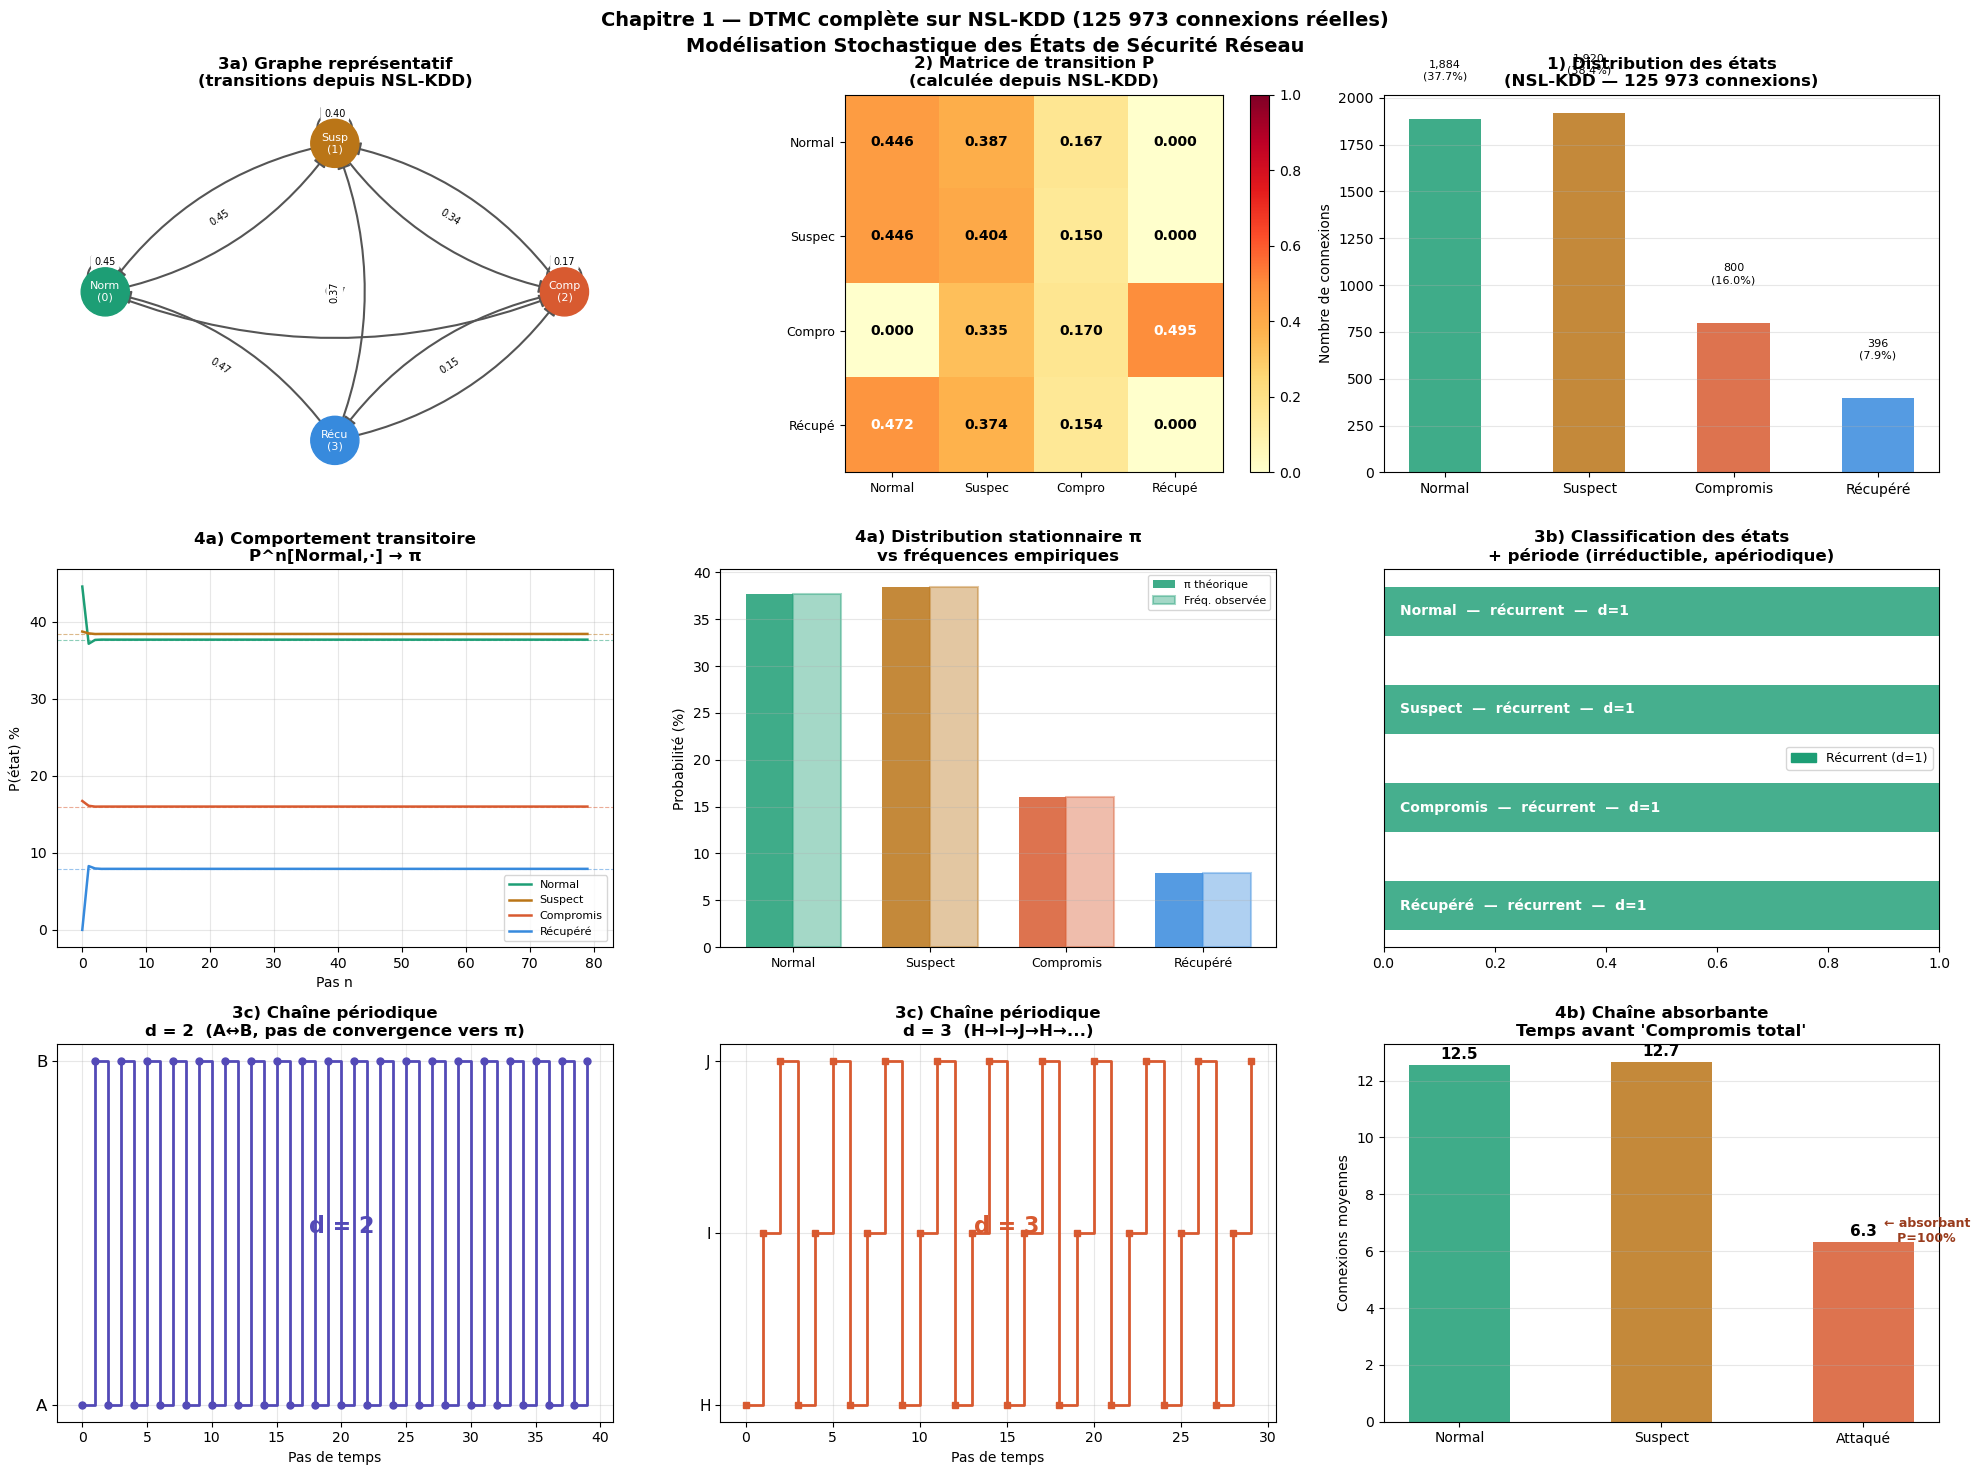


✅ Figure sauvegardée : ch1_dtmc_final_nslkdd.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
COUL = {0:"#1D9E75", 1:"#BA7517", 2:"#D85A30", 3:"#378ADD"}
 
fig = plt.figure(figsize=(20, 15))
fig.suptitle(
    "Chapitre 1 — DTMC complète sur NSL-KDD (125 973 connexions réelles)\n"
    "Modélisation Stochastique des États de Sécurité Réseau",
    fontsize=14, fontweight="bold"
)
 
# ── 1. Graphe des transitions ──
ax1 = fig.add_subplot(3, 3, 1)
pos = {0:(-1,0), 1:(0,1), 2:(1,0), 3:(0,-1)}
node_colors = [COUL[i] for i in range(4)]
edge_labels = {(i,j): f"{P[i,j]:.2f}"
               for i in range(4) for j in range(4) if P[i,j] > 0.01}
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1200, ax=ax1)
nx.draw_networkx_labels(G, pos,
    labels={i: f"{NOMS[i][:4]}\n({i})" for i in range(4)},
    font_size=8, font_color="white", ax=ax1)
nx.draw_networkx_edges(G, pos, ax=ax1, arrows=True, arrowstyle="-|>",
    arrowsize=20, connectionstyle="arc3,rad=0.2",
    edge_color="#555555", width=1.5)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
    font_size=7, ax=ax1)
ax1.set_title("3a) Graphe représentatif\n(transitions depuis NSL-KDD)", fontweight="bold")
ax1.axis("off")
 
# ── 2. Heatmap matrice P ──
ax2 = fig.add_subplot(3, 3, 2)
im = ax2.imshow(P, cmap="YlOrRd", vmin=0, vmax=1)
for i in range(4):
    for j in range(4):
        color = "white" if P[i,j] > 0.45 else "black"
        ax2.text(j, i, f"{P[i,j]:.3f}", ha="center", va="center",
                 fontsize=10, color=color, fontweight="bold")
ax2.set_xticks(range(4)); ax2.set_yticks(range(4))
ax2.set_xticklabels([n[:6] for n in NOMS], fontsize=9)
ax2.set_yticklabels([n[:6] for n in NOMS], fontsize=9)
ax2.set_title("2) Matrice de transition P\n(calculée depuis NSL-KDD)", fontweight="bold")
plt.colorbar(im, ax=ax2, fraction=0.046)
 
# ── 3. Distribution des états observés dans NSL-KDD ──
ax3 = fig.add_subplot(3, 3, 3)
dist_obs = [(df['etat']==i).sum() for i in range(4)]
bars3 = ax3.bar(NOMS, dist_obs, color=[COUL[i] for i in range(4)],
                alpha=0.85, width=0.5)
ax3.set_ylabel("Nombre de connexions")
ax3.set_title("1) Distribution des états\n(NSL-KDD — 125 973 connexions)", fontweight="bold")
ax3.grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, dist_obs):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f"{val:,}\n({val/len(df)*100:.1f}%)",
             ha='center', va='bottom', fontsize=8)
 
# ── 4. Convergence P^n ──
ax4 = fig.add_subplot(3, 3, 4)
evol = []
dist_ev = np.array([1., 0., 0., 0.])
for _ in range(80):
    dist_ev = dist_ev @ P
    evol.append(dist_ev.copy())
evol = np.array(evol)
for i in range(4):
    ax4.plot(evol[:, i]*100, color=COUL[i], label=NOMS[i], lw=1.8)
    ax4.axhline(pi[i]*100, color=COUL[i], ls="--", lw=0.8, alpha=0.5)
ax4.set_xlabel("Pas n"); ax4.set_ylabel("P(état) %")
ax4.set_title("4a) Comportement transitoire\nP^n[Normal,·] → π", fontweight="bold")
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)
 
# ── 5. Distribution stationnaire π vs fréquences empiriques ──
ax5 = fig.add_subplot(3, 3, 5)
x = np.arange(4); w = 0.35
freq_emp = [(df['etat']==i).sum()/len(df) for i in range(4)]
b1 = ax5.bar(x-w/2, [pi[i]*100 for i in range(4)], w,
             label="π théorique", color=[COUL[i] for i in range(4)], alpha=0.85)
b2 = ax5.bar(x+w/2, [freq_emp[i]*100 for i in range(4)], w,
             label="Fréq. observée", color=[COUL[i] for i in range(4)],
             alpha=0.4, edgecolor=[COUL[i] for i in range(4)], linewidth=1.5)
ax5.set_xticks(x); ax5.set_xticklabels(NOMS, fontsize=9)
ax5.set_ylabel("Probabilité (%)")
ax5.set_title("4a) Distribution stationnaire π\nvs fréquences empiriques", fontweight="bold")
ax5.legend(fontsize=8); ax5.grid(axis='y', alpha=0.3)
 
# ── 6. Classification des états ──
ax6 = fig.add_subplot(3, 3, 6)
for idx, i in enumerate(range(4)):
    c = classif[i]
    color = "#1D9E75" if c['type'] == 'récurrent' else "#D85A30"
    d = calculer_periode(P, i)
    ax6.barh(3-idx, 1, color=color, alpha=0.82, height=0.5)
    label = f"{NOMS[i]}  —  {c['type']}  —  d={d}"
    ax6.text(0.03, 3-idx, label, va='center', fontsize=10,
             color='white', fontweight='bold')
ax6.set_xlim(0,1); ax6.set_yticks([])
ax6.set_title("3b) Classification des états\n+ période (irréductible, apériodique)", fontweight="bold")
patches = [mpatches.Patch(color='#1D9E75', label='Récurrent (d=1)')]
ax6.legend(handles=patches, fontsize=9)
 
# ── 7. Chaîne périodique d=2 ──
ax7 = fig.add_subplot(3, 3, 7)
P_per2 = np.array([[0.,1.],[1.,0.]])
np.random.seed(42)
traj_d2 = [0]
e = 0
for _ in range(39):
    e = np.random.choice(2, p=P_per2[e])
    traj_d2.append(e)
ax7.step(range(40), traj_d2, color="#534AB7", lw=2, where="post",
         marker='o', markersize=5)
ax7.set_yticks([0,1]); ax7.set_yticklabels(["A","B"], fontsize=12)
ax7.set_xlabel("Pas de temps")
ax7.set_title("3c) Chaîne périodique\nd = 2  (A↔B, pas de convergence vers π)", fontweight="bold")
ax7.grid(alpha=0.3)
ax7.text(20, 0.5, "d = 2", fontsize=16, ha='center', color="#534AB7", fontweight='bold')
 
# ── 8. Chaîne périodique d=3 ──
ax8 = fig.add_subplot(3, 3, 8)
P_per3 = np.array([[0.,1.,0.],[0.,0.,1.],[1.,0.,0.]])
traj_d3 = [0]; e3 = 0
for _ in range(29):
    e3 = np.random.choice(3, p=P_per3[e3])
    traj_d3.append(e3)
ax8.step(range(30), traj_d3, color="#D85A30", lw=2, where="post",
         marker='s', markersize=5)
ax8.set_yticks([0,1,2]); ax8.set_yticklabels(["H","I","J"], fontsize=11)
ax8.set_xlabel("Pas de temps")
ax8.set_title("3c) Chaîne périodique\nd = 3  (H→I→J→H→...)", fontweight="bold")
ax8.grid(alpha=0.3)
ax8.text(15, 1, "d = 3", fontsize=16, ha='center', color="#D85A30", fontweight='bold')
 
# ── 9. Chaîne absorbante — temps avant compromission totale ──
ax9 = fig.add_subplot(3, 3, 9)
COUL_ABS = {0:"#1D9E75", 1:"#BA7517", 2:"#D85A30"}
noms_t_plot = [ETATS_ABS[i] for i in idx_trans]
bars9 = ax9.bar(noms_t_plot, t_abs,
                color=[COUL_ABS.get(i,"#888") for i in idx_trans],
                alpha=0.85, width=0.5)
ax9.set_ylabel("Connexions moyennes")
ax9.set_title("4b) Chaîne absorbante\nTemps avant 'Compromis total'", fontweight="bold")
ax9.grid(axis='y', alpha=0.3)
for bar, val in zip(bars9, t_abs):
    ax9.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{val:.1f}", ha='center', va='bottom', fontweight='bold', fontsize=11)
ax9.text(2.1, max(t_abs)*0.5, "← absorbant\n   P=100%",
         fontsize=9, color="#993C1D", fontweight='bold')
 
plt.tight_layout()
plt.savefig('ch1_dtmc_final_nslkdd.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Figure sauvegardée : ch1_dtmc_final_nslkdd.png")